# 05 Rule-based 분류 (SBC)

type×family 주간 시계열에 SBC를 적용해 4분류합니다. (실험 대상: **E·C, 66**)

| 클러스터 | 조건 | 의미 |
|----------|------|------|
| 1 Smooth | ADI<1.32, CV²<0.49 | 연속·안정 |
| 2 Intermittent | ADI≥1.32, CV²<0.49 | 간헐·저변동 |
| 3 Erratic | ADI<1.32, CV²≥0.49 | 연속·고변동 |
| 4 Lumpy | ADI≥1.32, CV²≥0.49 | 간헐·고변동 |

산출물: `sbc_cluster_type_family.parquet`


### SBC 계산

type×family별 ADI·CV²로 4분류 라벨을 부여합니다.


In [1]:
import sys
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# 경로 설정
NOTEBOOK_DIR = Path.cwd()
REPO_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == 'code' else NOTEBOOK_DIR
sys.path.insert(0, str(REPO_ROOT / 'code'))
from utils.paths import DATA_PROCESSED, SBC_CLUSTER
from utils.sbc import compute_sbc_table, ADI_TH, CV2_TH, CLUSTER_LABELS
from utils.config import filter_selected_types, selected_type_list

# SBC 4분류 계산 (임계값: ADI=1.32, CV²=0.49) — 실험 대상 2-type(E·C)만
dfw = pd.read_parquet(DATA_PROCESSED / 'df_weekly.parquet')
dfw = filter_selected_types(dfw)
sbc = compute_sbc_table(dfw, ['type', 'family'], qty_col='sales')
print('실험 대상 type:', selected_type_list())
print(sbc['SBC_CLUSTER_LABEL'].value_counts())
sbc.head()

실험 대상 type: ['E', 'C']
SBC_CLUSTER_LABEL
Smooth          38
Intermittent    19
Lumpy            6
Erratic          3
Name: count, dtype: int64


,type,family,ADI,CV2,SBC_CLUSTER,SBC_CLUSTER_LABEL,n_periods,n_positive
0,C,AUTOMOTIVE,1.000000,0.063214,1,Smooth,242,242
1,C,BABY CARE,1.847328,0.370534,2,Intermittent,242,131
2,C,BEAUTY,1.000000,0.168038,1,Smooth,242,242
3,C,BEVERAGES,1.000000,0.187246,1,Smooth,242,242
4,C,BOOKS,NaN,NaN,4,Lumpy,242,0


### type별 분포

Smooth / Intermittent / Erratic / Lumpy 교차표.


In [2]:
# type × SBC 클러스터 교차표
print(sbc.groupby(['type', 'SBC_CLUSTER_LABEL']).size().unstack(fill_value=0))


SBC_CLUSTER_LABEL  Erratic  Intermittent  Lumpy  Smooth
type                                                   
C                        1            10      3      19
E                        2             9      3      19


### ADI vs CV²

경계선 ADI=1.32, CV²=0.49.


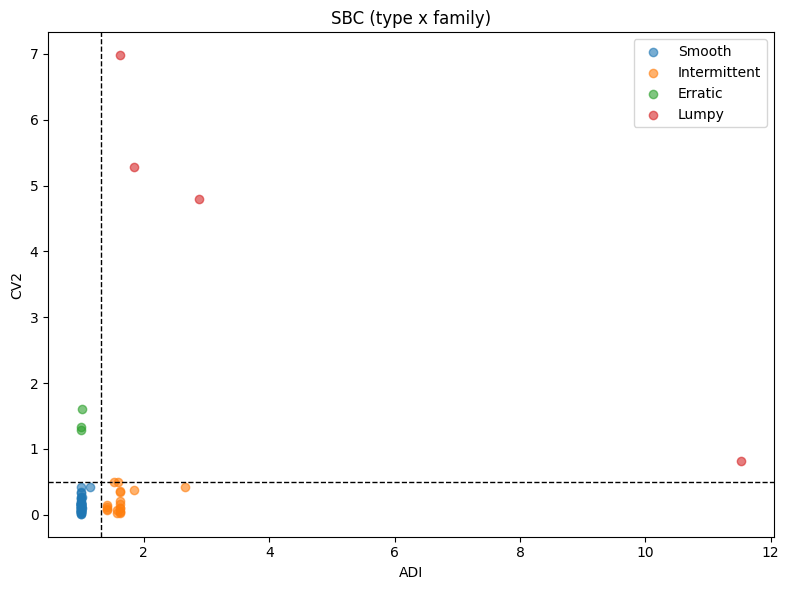

In [3]:
# ADI-CV² 4분면 산점도 (점 = type×family 1개 시계열)
plt.figure(figsize=(8, 6))
for cl, g in sbc.groupby('SBC_CLUSTER'):
    plt.scatter(g['ADI'], g['CV2'], alpha=0.6, label=CLUSTER_LABELS[cl])
plt.axvline(ADI_TH, color='k', ls='--', lw=1)   # ADI=1.32 경계
plt.axhline(CV2_TH, color='k', ls='--', lw=1)  # CV²=0.49 경계
plt.xlabel('ADI'); plt.ylabel('CV2'); plt.title('SBC (type x family)')
plt.legend(); plt.tight_layout(); plt.show()


### 저장

`sbc_cluster_type_family.parquet` — 이후 예측 실험의 rule-base 축.


In [4]:
# SBC 라벨 parquet 저장 → 07~10장 예측 실험 조건 축
sbc.to_parquet(SBC_CLUSTER, index=False)
print('저장:', SBC_CLUSTER)


저장: C:\Users\kjh\ai-retail-demandforecasting\data\processed\sbc_cluster_type_family.parquet


## 분석 요약

| 클러스터 | 개수 | 비율 |
|----------|------|------|
| Smooth | 38 | 57.6% |
| Intermittent | 19 | 28.8% |
| Lumpy | 6 | 9.1% |
| Erratic | 3 | 4.5% |

| type | Smooth | Intermittent | Erratic | Lumpy |
|------|--------|--------------|---------|-------|
| C | 19 | 10 | 1 | 3 |
| E | 19 | 9 | 2 | 3 |

임계값 1.32/0.49는 학위논문과 동일. 07~11장 rule-base 클러스터 축으로 사용합니다.
